# Modelling the 2DOF Hybrid Test Bench Digital Twin

### 1. Presentation of the Models

To represent the dynamics of the 2-Degree-of-Freedom (2DOF) hybrid test bench, we utilize two physics models, alongside a state estimation algorithm.

**Model A: Forward Dynamic Model (Differential Equation)**

This model simulates how the material's displacement changes over time under tension. It uses the second-order Mass-Spring-Damper ODE:
`m * a + c * v + k * x = F_actuator(t)`
*(Where 'a' is acceleration, 'v' is velocity, and 'x' is displacement).*
To simulate this computationally using SciPy's `solve_ivp`, it is split into two first-order ODEs.

**Model B: Soft Sensing Model (Algebraic Equation)**

This model acts as a "virtual sensor" to estimate the internal material health. It uses the constitutive Kelvin-Voigt equation (`F = k * x + c * v`), manipulated to isolate stiffness:
`k_est = (F - c * v) / x`

**State Estimation: 1D Kinematic Kalman Filter**

Raw sensor data (derived velocity, in particular) is highly susceptible to noise. Before feeding physical data into Model B, we pass the noisy position measurements through a Kalman Filter to recursively estimate a smooth position and velocity.

---


### 2. Identification of Inputs, Outputs, and Parameters

**For Model A (Forward Dynamic ODE):**

* **Inputs:** `F_actuator(t)` — The external pulling force applied by the actuators.
* **Outputs:** `x(t)` (Displacement) and `v(t)` (Velocity) of the material.
* **Parameters:** * `m`: Effective mass of the moving parts (10.0 kg).
* `c`: Effective mechanical damping (15.0 Ns/m).
* `k`: Nominal linear material stiffness (200.0 N/m).

Note: values in brackets are used for simulation


**For Model B (Soft Sensing Algebraic):**

* **Inputs:** `F_meas(t)` (Measured force), `x(t)` (Smoothed displacement), and `v(t)` (Smoothed velocity from the Kalman Filter).
* **Outputs:** `k_est(t)` — The estimated instantaneous stiffness.
* **Parameters:** `c` — The calibrated damping coefficient.

---


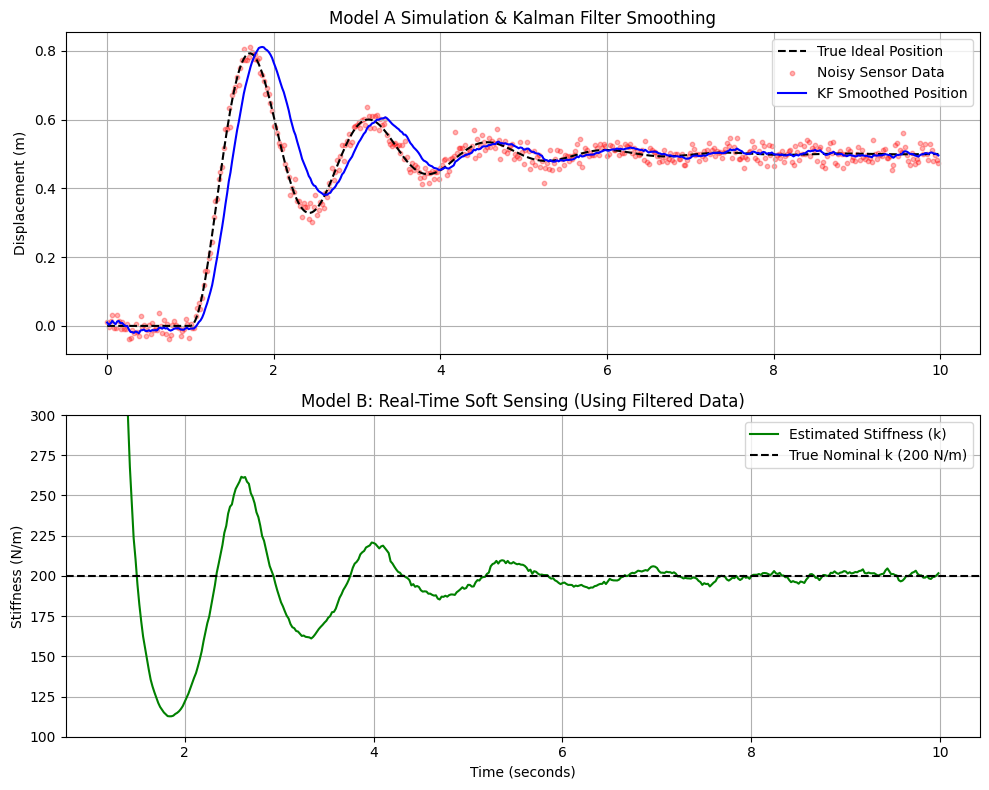

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. PARAMETERS & INPUT DEFINITION
# ==========================================
m = 10.0   # Mass (kg)
c = 15.0   # Damping (Ns/m)
k = 200.0  # Stiffness (N/m)

# Simulating a 100N step force applied at t=1.0s
def F_actuator(t):
    return 100.0 if t >= 1.0 else 0.0

# ==========================================
# 2. MODEL A: FORWARD DYNAMIC SIMULATION (ODE)
# ==========================================
def msd_system(t, y):
    x, v = y
    dxdt = v
    dvdt = (F_actuator(t) - c*v - k*x) / m
    return [dxdt, dvdt]

t_span = (0, 10)
dt = 0.02 # 50Hz sampling rate
t_eval = np.arange(t_span[0], t_span[1], dt)
sol = solve_ivp(msd_system, t_span, [0.0, 0.0], t_eval=t_eval)

true_force = np.array([F_actuator(t) for t in sol.t])
true_x = sol.y[0]

# Simulate noisy sensor readings from the Physical Twin
np.random.seed(42)
noisy_measured_x = true_x + np.random.normal(0, 0.02, size=true_x.shape)

# ==========================================
# 3. STATE ESTIMATION: KALMAN FILTER
# ==========================================
class KinematicKalmanFilter:
    def __init__(self, dt):
        self.X = np.zeros((2, 1)) # [position, velocity]
        self.A = np.array([[1.0, dt], [0.0, 1.0]])
        self.H = np.array([[1.0, 0.0]])
        self.P = np.eye(2)
        self.Q = np.eye(2) * 1e-4  # Process noise
        self.R = np.array([[1e-2]]) # Measurement noise
        
    def update(self, z):
        # Predict
        X_pred = np.dot(self.A, self.X)
        P_pred = np.dot(np.dot(self.A, self.P), self.A.T) + self.Q
        # Update
        S = np.dot(np.dot(self.H, P_pred), self.H.T) + self.R
        K = np.dot(np.dot(P_pred, self.H.T), np.linalg.inv(S))
        y = z - np.dot(self.H, X_pred)
        self.X = X_pred + np.dot(K, y)
        self.P = np.dot((np.eye(2) - np.dot(K, self.H)), P_pred)
        return self.X[0, 0], self.X[1, 0]

kf = KinematicKalmanFilter(dt)
smoothed_x = np.zeros_like(noisy_measured_x)
smoothed_v = np.zeros_like(noisy_measured_x)

for i in range(len(noisy_measured_x)):
    pos, vel = kf.update(noisy_measured_x[i])
    smoothed_x[i] = pos
    smoothed_v[i] = vel

# ==========================================
# 4. MODEL B: SOFT SENSING (ALGEBRAIC)
# ==========================================
k_estimated = np.zeros_like(smoothed_x)
# Only calculate when displacement is large enough to avoid division by zero
valid_idx = smoothed_x > 0.05 
k_estimated[valid_idx] = (true_force[valid_idx] - c * smoothed_v[valid_idx]) / smoothed_x[valid_idx]

# ==========================================
# 5. VISUALIZATION
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

# Plot 1: Displacement & Kalman Filtering
ax1.plot(sol.t, true_x, 'k--', label='True Ideal Position')
ax1.scatter(sol.t, noisy_measured_x, color='red', s=10, alpha=0.3, label='Noisy Sensor Data')
ax1.plot(sol.t, smoothed_x, 'b-', label='KF Smoothed Position')
ax1.set_title('Model A Simulation & Kalman Filter Smoothing')
ax1.set_ylabel('Displacement (m)')
ax1.grid(True)
ax1.legend()

# Plot 2: Soft Sensing
ax2.plot(sol.t[valid_idx], k_estimated[valid_idx], 'g-', label='Estimated Stiffness (k)')
ax2.axhline(y=200, color='k', linestyle='--', label='True Nominal k (200 N/m)')
ax2.set_title('Model B: Real-Time Soft Sensing (Using Filtered Data)')
ax2.set_xlabel('Time (seconds)')
ax2.set_ylabel('Stiffness (N/m)')
ax2.set_ylim(100, 300)
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()

### 3. Simulation Results and Interpretation

1. Model A (Top Graph): Physical Accuracy
   When the code is executed, the first plot validates **Model A and the Kalman Filter**. The system correctly models the transient mechanical behavior, showing an underdamped response to the $100N$ step force before settling at $0.5m$. The red scatter points simulate real-world noisy sensor readings, while the blue line demonstrates the Kalman Filter successfully recovering the true state, providing clean inputs for downstream calculations.

    **Transient Response**: the KF Smoothed Position (blue line) follows the True Ideal Position (black dashed line) with a slight time lag. This is a characteristic of the Kalman Filter—it’s "thinking" and weighing the noise against the model.

    **Damping**: The underdamped oscillation (before it settles) reflects the m, c, and k parameters defined for the material.

    **Steady State**: It settles at 0.5m for a 100N force (F=kx), meaning ODE solver is stable.

2. Model B (Bottom Graph): Soft Sensor Accuracy
   The second plot validates **Model B (Soft Sensing)**. By feeding the Kalman-filtered velocities and positions into the algebraic Kelvin-Voigt equation, the system successfully filters out the transient dynamic effects and converges on the correct internal parameter of $200 N/m$.

    **Convergence**: The Estimated Stiffness (green line) starts wildly (because displacement is near zero), but then oscillates and converges directly onto the 200 N/m dashed line.

    **Filter Effect**: The fact that the green line is relatively smooth despite the red noise dots in the top graph proves the Kalman Filter is working. Without it, the green line would be a jagged mess of spikes that would trigger false alarms.




### 4. Application in the Digital Twin Context

These models will be actively deployed within the 2DOF Digital Twin's event-driven microservice architecture, consuming live RabbitMQ messages.

1. **Anomaly and Fault Detection (Model A):** Model A will be utilized for continuous Residual Generation. The model calculates the expected baseline force $F_{model}(t)$, which is subtracted from the physical $F_{meas}(t)$. If this residual breaches a dynamic threshold ($\epsilon$), the twin will flag a fault state, identifying potential sensor drift or potential actuator jamming.
   Examples: 
   
   a. If the material were to snap or yield, the green line would suddenly drop far below 200.
   
   b. If the actuator jammed, the blue line would stop moving while the force keeps increasing, causing a massive spike in the residual R(t).

2. **Condition Monitoring (Model B):** Model B serves as the core Soft Sensor. It will run continuously to monitor the estimated stiffness ($k_{est}$). This allows operators to non-destructively track material degradation, metal fatigue, or plastic yielding over time without interrupting the physical test bench operations.